In [1]:
from utils.paths import RAW_DIR,DATABASE_DIR,PREDICTIONS_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from features.DescriptorEngineer import ElementPropertyLoader,AlloyDescriptorCalculator
import umap
import hdbscan
from hdbscan import approximate_predict

In [2]:
from utils.paths import RAW_DIR,DATABASE_DIR,PREDICTIONS_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.Descriptors import AlloyDescriptorCalculator
from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength

Data correlation experimental data

In [3]:
calc = AlloyDescriptorCalculator()

In [10]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge ---
df_merged = merge_data(df_optical, df_comp)
# --- Filter ---
tern_1550 = filter_by_wavelength(df_merged, 1552.0)
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[['ID','resistivity']])

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [11]:
df_comp = tern_1550[['Cu','Ni','Al','e2','resistivity']]

In [12]:
calc = AlloyDescriptorCalculator()

descriptor_spec = {
    "atomic_radius": ["avg","mismatch", "range"],
    "metallic_radius": ["avg","mismatch", "range"],
    "electronegativity_pauling": ["avg","mismatch", "range"],
    "electronegativity_allen": ["avg","mismatch", "range"],
    "valence_electrons": ["avg","mismatch", "range"],
    "density": ["avg","mismatch", "range"],
    "electron_affinity": ["avg","mismatch", "range"],
    "ionization_energy_1": ["avg","mismatch", "range"]
}

df_desc = calc.transform(df_comp, descriptor_spec=descriptor_spec, include_entropy=True)

In [18]:
corr_pearson = df_desc.corr(numeric_only=True)
target = "e2"

corr_target_pearson = corr_pearson[target].sort_values(ascending=False)
corr_target_pearson = corr_target_pearson.drop(target)

In [19]:
corr_target_pearson

Al             0.669486
mr_avg         0.572783
resistivity    0.450263
del_ea         0.227943
del_ie1        0.227706
del_d          0.227374
del_ve         0.227294
del_ep         0.226765
del_ar         0.222797
del_mr         0.197378
min_maxmr      0.173763
min_maxep      0.150278
min_maxar      0.147051
min_maxd       0.144127
min_maxie1     0.131015
min_maxea      0.112983
min_maxve      0.102127
S              0.028535
Ni            -0.089944
Cu            -0.606966
ar_avg        -0.650958
ep_avg        -0.653749
d_avg         -0.670145
ie1_avg       -0.675362
ea_avg        -0.689202
ve_avg        -0.694621
Name: e2, dtype: float64

In [22]:
corr_spearman = df_desc.corr(method="kendall",numeric_only=True)
target = "e2"

corr_target_spearman = corr_spearman[target].sort_values(ascending=False)
corr_target_spearman = corr_target_spearman.drop(target)

In [23]:
corr_target_pearson

Al             0.669486
mr_avg         0.572783
resistivity    0.450263
del_ea         0.227943
del_ie1        0.227706
del_d          0.227374
del_ve         0.227294
del_ep         0.226765
del_ar         0.222797
del_mr         0.197378
min_maxmr      0.173763
min_maxep      0.150278
min_maxar      0.147051
min_maxd       0.144127
min_maxie1     0.131015
min_maxea      0.112983
min_maxve      0.102127
S              0.028535
Ni            -0.089944
Cu            -0.606966
ar_avg        -0.650958
ep_avg        -0.653749
d_avg         -0.670145
ie1_avg       -0.675362
ea_avg        -0.689202
ve_avg        -0.694621
Name: e2, dtype: float64

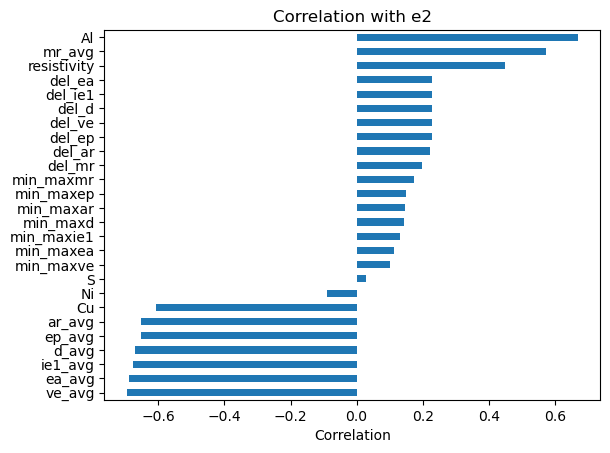

In [14]:
import matplotlib.pyplot as plt

corr_target.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Correlation with {target}")
plt.xlabel("Correlation")
plt.show()

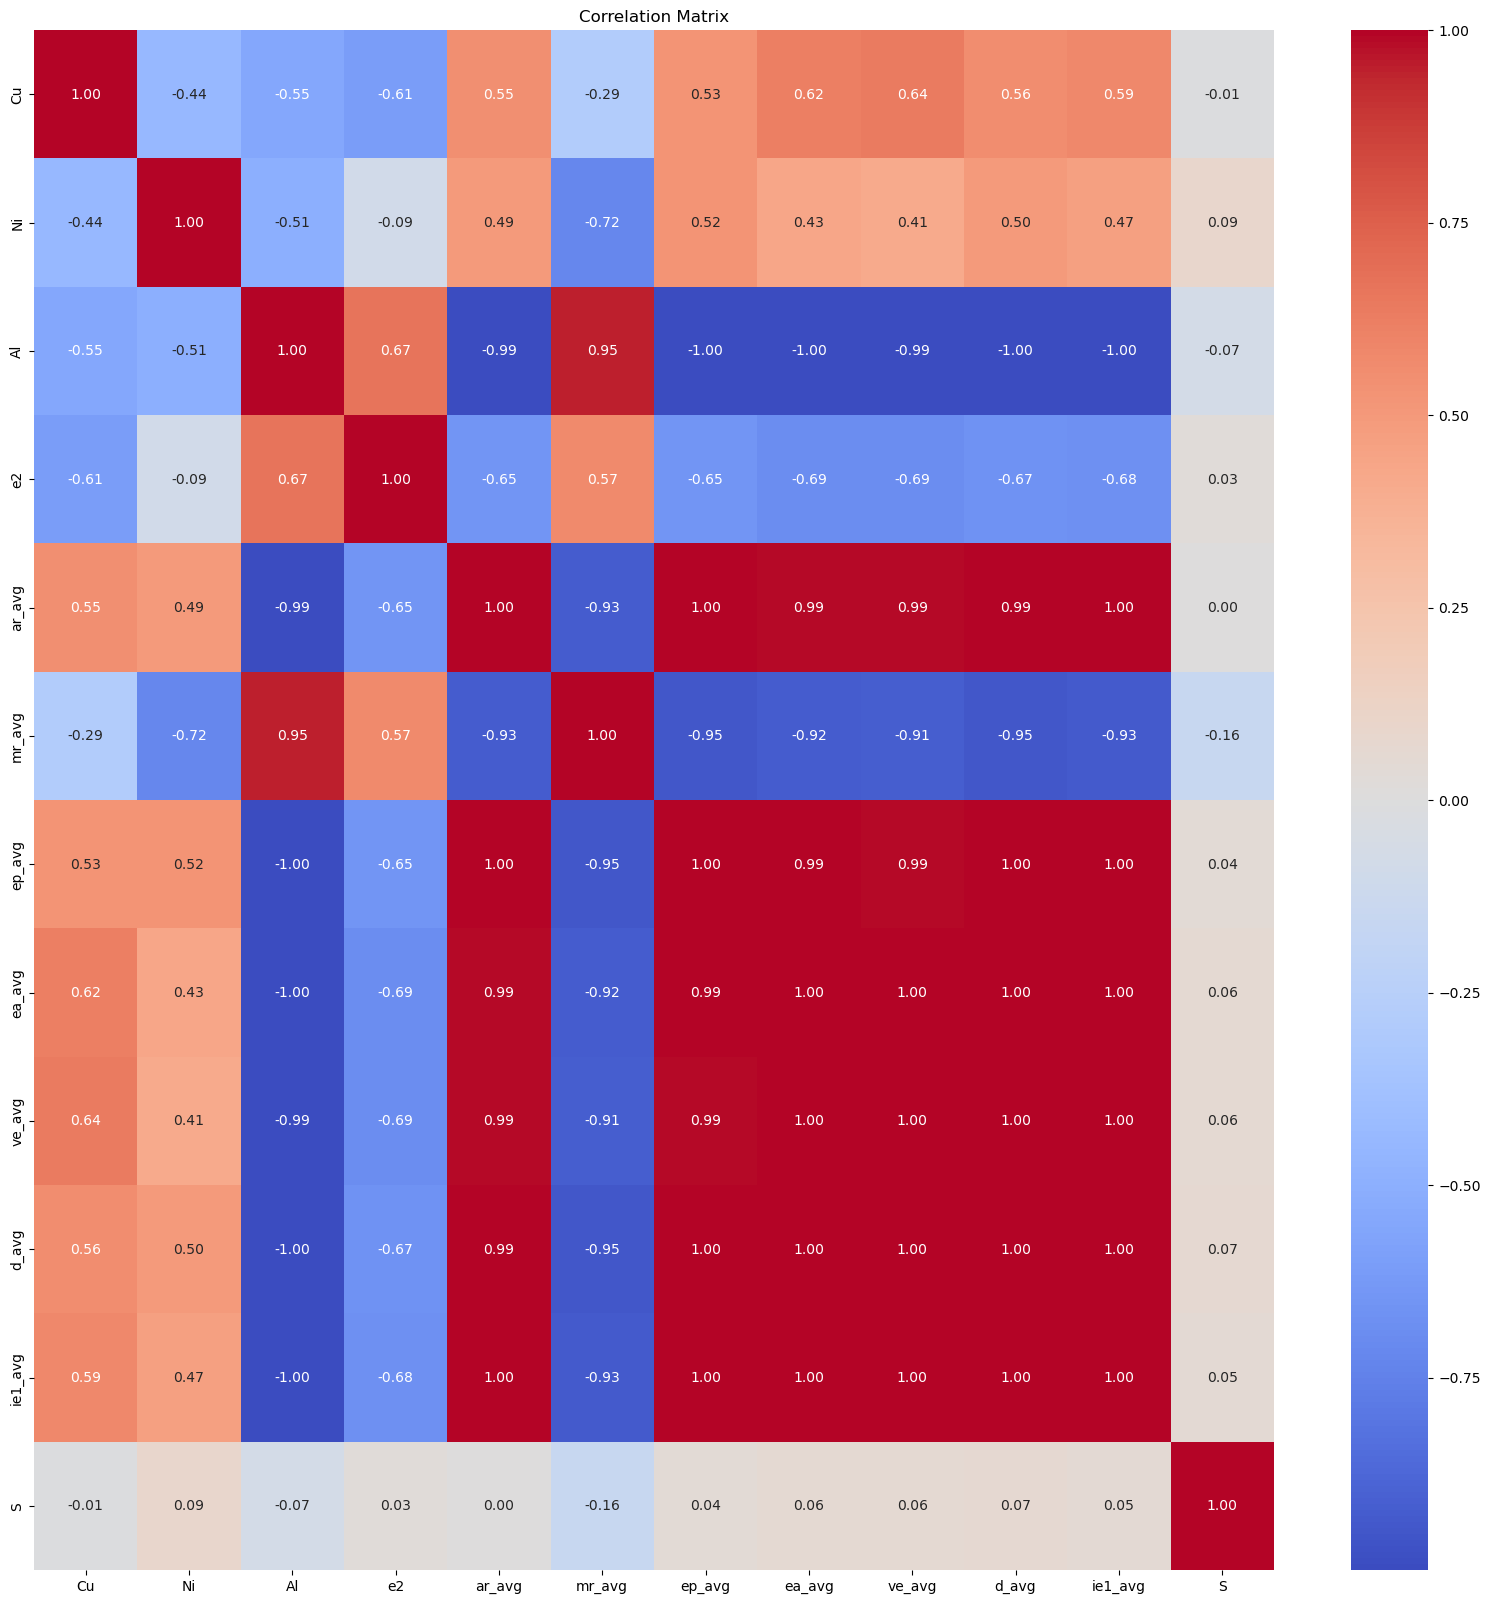

In [7]:
corr = df_desc.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [20]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc_2 = AlloyDescriptorCalculator(elem_props=elem_props)

In [21]:
df_com_2 = calc_2.transform(tern_1550[['Cu','Ni','Al','e2']])

In [24]:
df_com_2.head(5)

,Cu,Ni,Al,e2,r,del_r,del_EN,S,VEC
0,0.95,0.05,0.00,37.692028,1.2780,0.006821,0.002179,1.650456,10.95
1,0.95,0.00,0.05,15.960722,1.2875,0.025392,0.063204,1.650456,10.60
2,0.00,0.95,0.05,56.649986,1.2495,0.033141,0.065383,1.650456,9.65
3,0.05,0.95,0.00,56.370949,1.2420,0.007019,0.002179,1.650456,10.05
4,0.05,0.00,0.95,64.696091,1.4225,0.022982,0.063204,1.650456,3.40


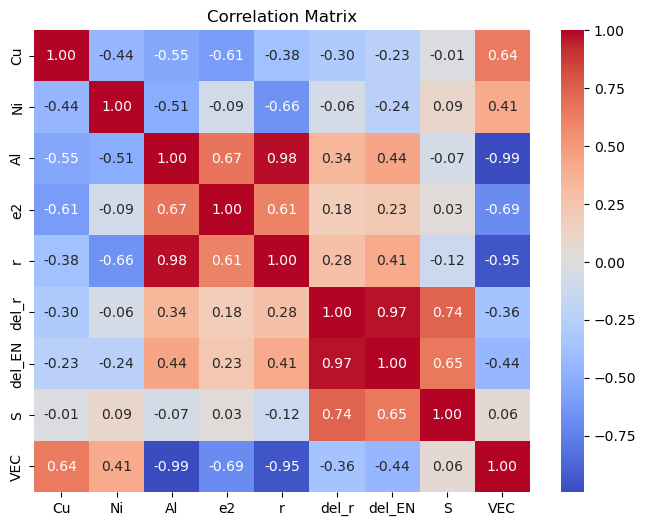

In [23]:
corr = df_com_2.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

Data Correlation
1. ANN descriptors with resistivity
2. Experimental data with e2

In [2]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['t','depo','H','r','del_r','del_EN','S','VEC','Th','resistivity']
ann_data_corr = ann_data[cols]

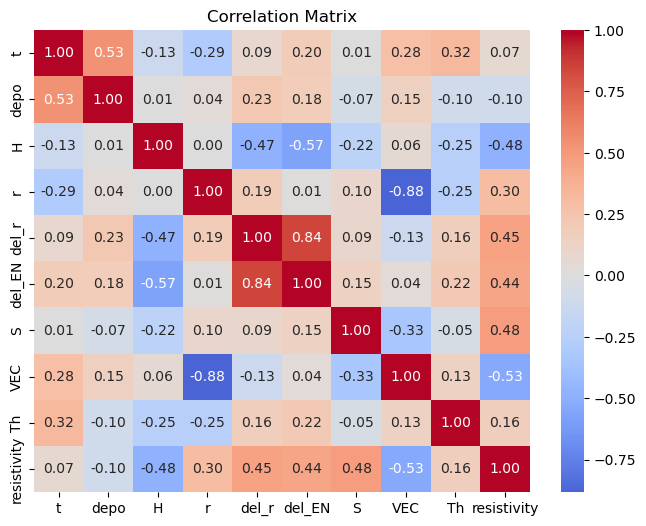

In [3]:
corr = ann_data_corr.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

ANN Data

In [2]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['r','del_r','del_EN','S','VEC']
ann_data_per = ann_data[cols]

Experimental data

In [3]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [ ]:
X_exp = comp_space[['Cu','Ni','Al']].copy()
Xexp = calc.transform(X_exp)
Xexp = Xexp[cols]

In [7]:
# Standarize
scaler = MinMaxScaler()
X_scale = scaler.fit_transform(ann_data_per)

# Apply PCA training set
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Apply PCA new points data
x_exp_scale = scaler.transform(Xexp)
x_exp_pca = pca.transform(x_exp_scale)
df_exp_pca = pd.DataFrame(x_exp_pca, columns=["PC1", "PC2"])

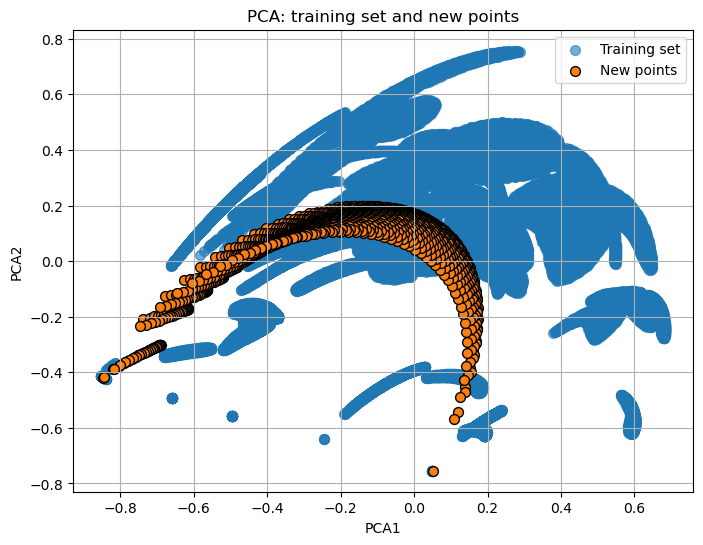

In [8]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_pca["PC1"],
    df_exp_pca["PC2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


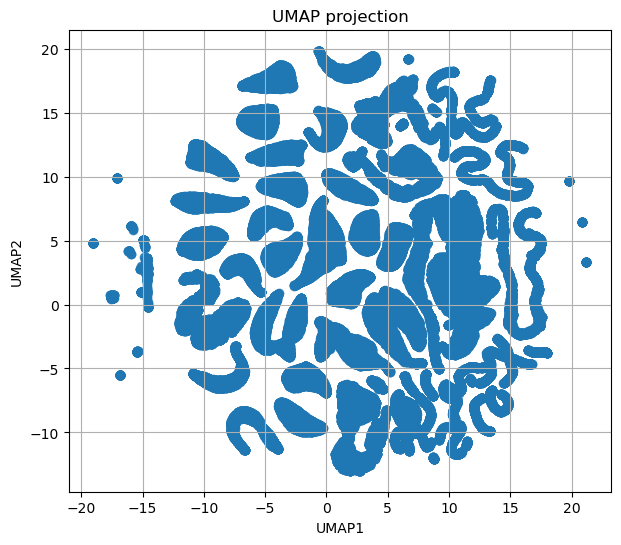

In [9]:
# UMAP model
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Fit and transform
X_umap = reducer.fit_transform(X_scale)

# Put into dataframe
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"], index=ann_data_per.index)

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(df_umap["UMAP1"], df_umap["UMAP2"], alpha=0.8)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projection")
plt.grid(True)
plt.show()

In [10]:
x_exp_scale = scaler.transform(Xexp)
x_exp_umap = reducer.transform(x_exp_scale)
df_exp_umap = pd.DataFrame(x_exp_umap, columns=["UMAP1", "UMAP2"])

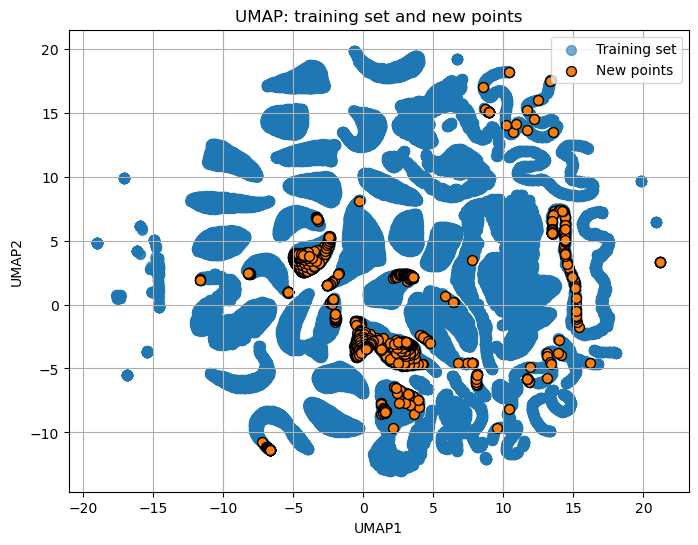

In [11]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_umap["UMAP1"],
    df_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_umap["UMAP1"],
    df_exp_umap["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

Clustering Method

In [12]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50,prediction_data=True)
labels = clusterer.fit_predict(X_umap)
df_umap["cluster"] = labels

In [13]:
# Assign clusters to experimental points
labels_exp, strengths = approximate_predict(clusterer, df_exp_umap[["UMAP1","UMAP2"]].values)
df_exp_umap["cluster"] = labels_exp
df_exp_umap["strength"] = strengths

In [14]:
#Unique clusters labels from the CuNiAl system
relevant_clusters = df_exp_umap["cluster"].unique()
relevant_clusters = relevant_clusters[relevant_clusters != -1]
print(relevant_clusters)

[32 30 29 27 22 12 21 23  6 47 64 62 53  2 41 61 39 28 26 48 20 43 51 60]


In [15]:
# Extract the data from those clusters from the dataset data
df_selected_umap = df_umap[df_umap["cluster"].isin(relevant_clusters)].copy()

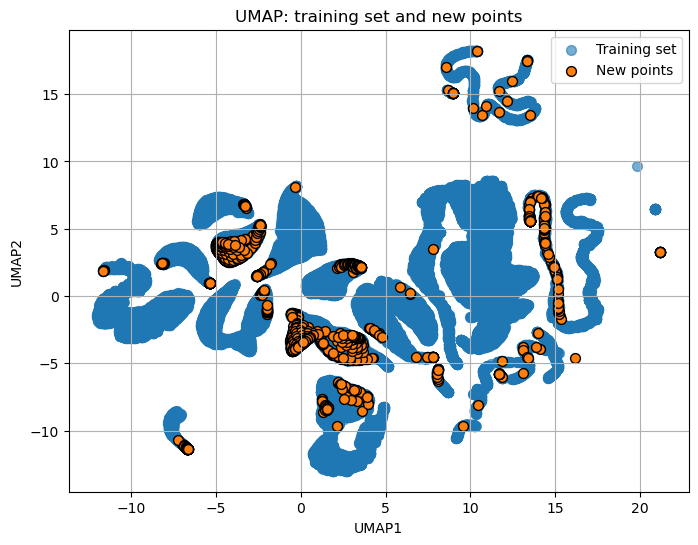

In [16]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_selected_umap["UMAP1"],
    df_selected_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_umap["UMAP1"],
    df_exp_umap["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ann_data_selected = ann_data.loc[df_selected_umap.index]
ann_data_selected.to_csv("selected_data.csv",index=False)

In [24]:
ann_data_selected = ann_data_selected[cols]

selected_scale = scaler.transform(ann_data_selected)
selected_umap = reducer.transform(selected_scale)
df_sel_umap = pd.DataFrame(selected_umap, columns=["UMAP1", "UMAP2"])

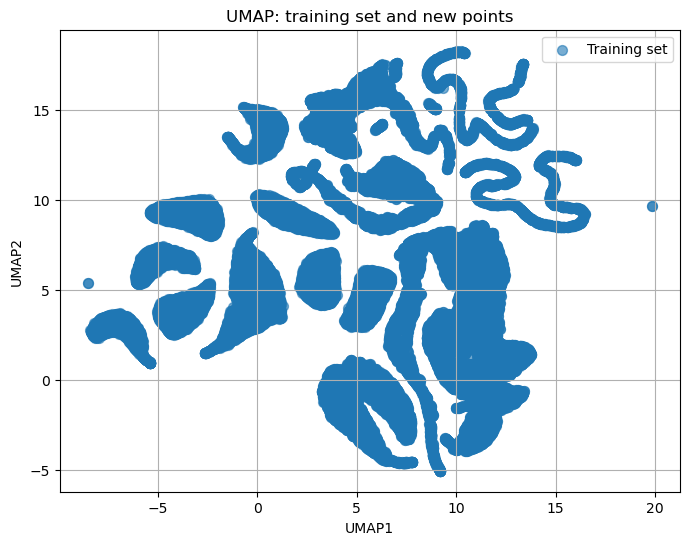

In [25]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_sel_umap["UMAP1"],
    df_sel_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()